# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [39]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [40]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [41]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі ПІСЛЯ, викликаючи `set_seed()`. Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [42]:
numbers = list(range(10))  # список для shuffle

print("--- ДО set_seed(), спроба 1 ---")
print("randint:", random.randint(1, 100))
nums_copy = numbers.copy()
random.shuffle(nums_copy)
print("shuffle:", nums_copy)

print("--- ДО set_seed(), спроба 2 ---")
print("randint:", random.randint(1, 100))
nums_copy = numbers.copy()
random.shuffle(nums_copy)
print("shuffle:", nums_copy)

set_seed()
print("Seed зафіксовано:", SEED)

print("--- ПІСЛЯ set_seed(), спроба 1 ---")
set_seed()
print("randint:", random.randint(1, 100))
nums_copy = numbers.copy()
random.shuffle(nums_copy)
print("shuffle:", nums_copy)

print("--- ПІСЛЯ set_seed(), спроба 2 ---")
set_seed()
print("randint:", random.randint(1, 100))
nums_copy = numbers.copy()
random.shuffle(nums_copy)
print("shuffle:", nums_copy)


--- ДО set_seed(), спроба 1 ---
randint: 4
shuffle: [7, 6, 2, 9, 0, 5, 1, 8, 3, 4]
--- ДО set_seed(), спроба 2 ---
randint: 5
shuffle: [6, 7, 2, 9, 5, 4, 8, 3, 1, 0]
Seed зафіксовано: 42
--- ПІСЛЯ set_seed(), спроба 1 ---
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
--- ПІСЛЯ set_seed(), спроба 2 ---
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]


До виклику `set_seed()` кожен раз `random.randint()` і `random.shuffle()` дають різні результати, тому що генератор випадкових чисел кожного разу починає роботу з іншого стану.
Після виклику `set_seed(42)` задається фіксований початковий стан для генератора. Тому, якщо перед кожним викликом знову встановлювати `set_seed(42)`, результати будуть однаковими.
Це потрібно для того, щоб результати експериментів можна було повторити. Наприклад, при повторному запуску програми можна отримати той самий набір даних або ті самі випадкові значення.


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [43]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [44]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [45]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [46]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [47]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)
print("ndim identity:", identity.ndim, " ndim random_ints:", random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]
ndim identity: 2  ndim random_ints: 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [48]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [49]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [50]:
df = pd.DataFrame({
    "name": ["Ivan", "Olena", "Petro", "Maria", "Sergii", "Anna"],
    "score": [78, 85, 92, 67, 90, 74],
})

top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)


     name  score
2   Petro     92
4  Sergii     90
1   Olena     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [51]:
def to_grade(score):
    if score >= 90:
        return "A"
    elif score >= 75:
        return "B"
    else:
        return "C"

df["grade"] = df["score"].apply(to_grade)
print(df)


     name  score grade
0    Ivan     78     B
1   Olena     85     B
2   Petro     92     A
3   Maria     67     C
4  Sergii     90     A
5    Anna     74     C


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [52]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t, zeros_t.shape, zeros_t.dtype)
print(sevens_t, sevens_t.shape, sevens_t.dtype)


tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3]) torch.float32
tensor([[7, 7, 7],
        [7, 7, 7]]) torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [53]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [54]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list, from_list.shape, from_list.dtype, from_list.ndim)
print(random_t, random_t.shape, random_t.dtype, random_t.ndim)


tensor([[1, 2],
        [3, 4]]) torch.Size([2, 2]) torch.int64 2
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]]) torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [55]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print("Автоматичний градієнт:", x.grad.item())
print("Аналітичний градієнт (2 * n):", 2 * n)


Автоматичний градієнт: 10.0
Аналітичний градієнт (2 * n): 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [56]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

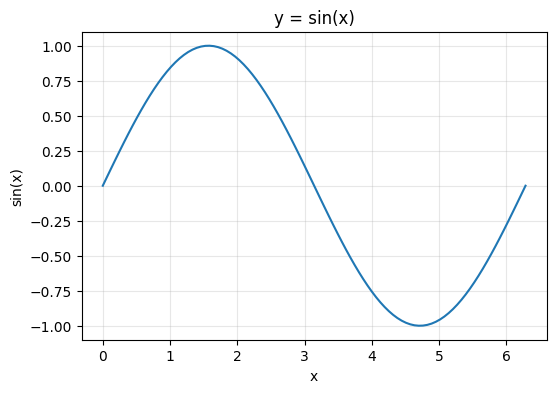

In [57]:
xs = np.linspace(0, 2 * np.pi, 100)
plt.figure(figsize=(6, 4))
plt.plot(xs, np.sin(xs))
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("y = sin(x)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

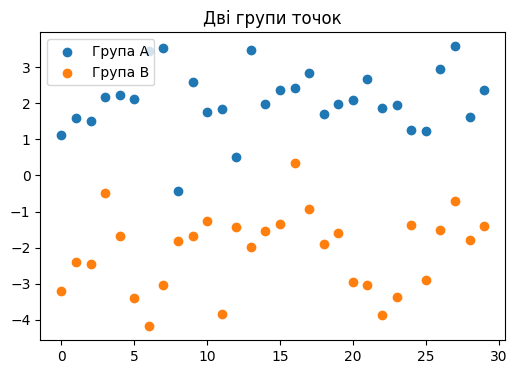

In [58]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.figure(figsize=(6, 4))
plt.scatter(range(len(group_a)), group_a, color="C0", label="Група A")
plt.scatter(range(len(group_b)), group_b, color="C1", label="Група B")
plt.legend()
plt.title("Дві групи точок")
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [59]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

[Текст ссылки](https://)**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

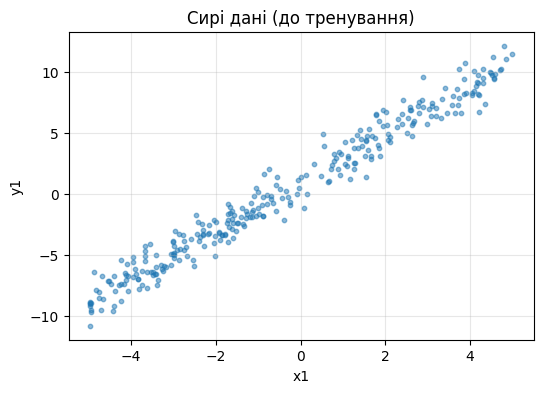

In [60]:
plt.figure(figsize=(6, 4))
plt.scatter(x1.numpy(), y1.numpy(), s=10, alpha=0.5)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [61]:
perm = torch.randperm(TASK1_N)
x1_shuf, y1_shuf = x1[perm], y1[perm]

n_train = int(0.70 * TASK1_N)
n_val = int(0.15 * TASK1_N)

x_train1, y_train1 = x1_shuf[:n_train], y1_shuf[:n_train]
x_val1, y_val1 = x1_shuf[n_train:n_train + n_val], y1_shuf[n_train:n_train + n_val]
x_test1, y_test1 = x1_shuf[n_train + n_val:], y1_shuf[n_train + n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [62]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


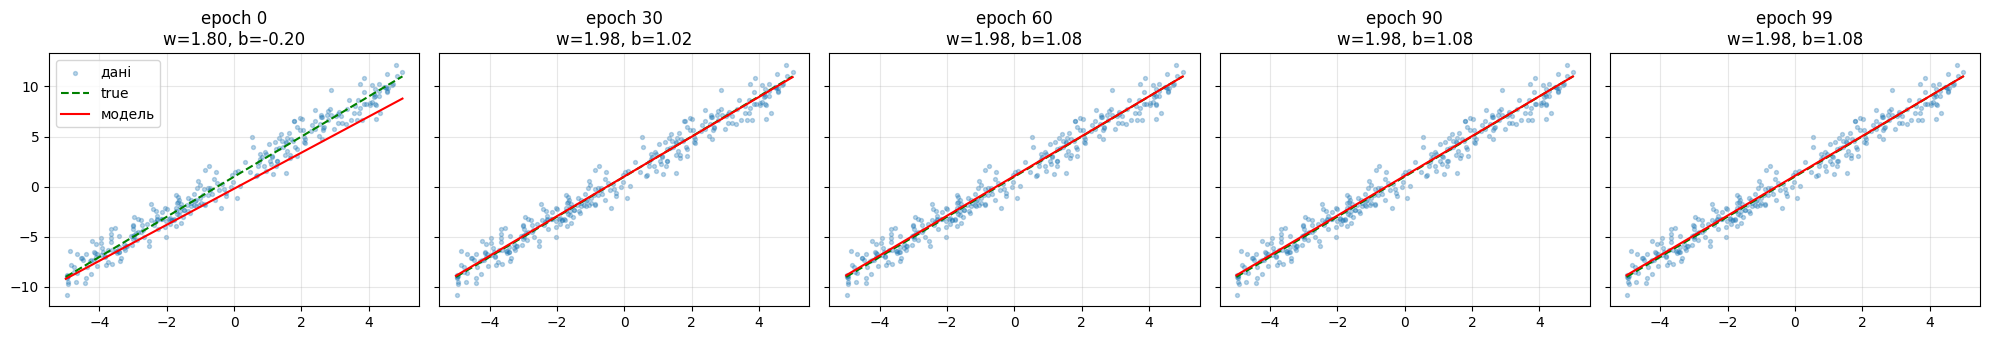

In [63]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

**Мій сценарій.** Роки досвіду роботи в IT → зарплата (умовні одиниці, наприклад тисячі грн/міс).

Закладаю залежність $y = w \cdot x + b + \varepsilon$, де:
- $w = 300.0$ — кожен додатковий рік досвіду в середньому додає ~300 умовних одиниць до зарплати (ринок праці в IT явно винагороджує стаж — джуніор і мідл з різницею в 3-4 роки досвіду зазвичай отримують помітно різну зарплату);
- $b = 600.0$ — стартова зарплата новачка без досвіду (0 років) не нульова, бо навіть junior-позиція оплачується;
- реалістичний діапазон досвіду $x \in [0, 15]$ років (від щойного випускника до досвідченого спеціаліста), а зарплату обрізається знизу нулем (від'ємної зарплати не буває);
- шум $\varepsilon \sim \mathcal{N}(0, 150)$ — компанія, стек технологій, переговорні навички, регіон і формат роботи вносять помітний розкид навколо лінійної залежності від самого лише стажу.

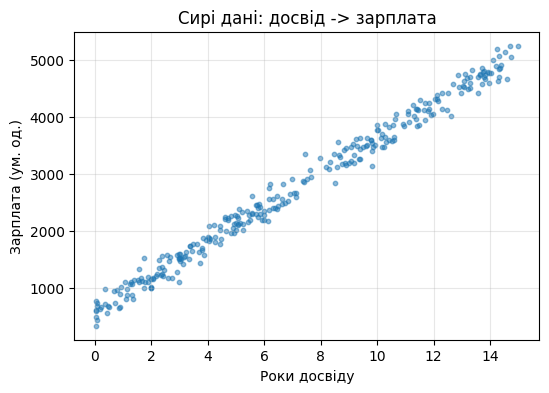

Збережено датасет у: /content/drive/MyDrive/ai_systems/lab1/dataset.csv


,experience_years,salary
0,13.234039,4486.633789
1,13.725060,4572.266113
2,5.742956,2453.578613
3,14.389585,4902.529297
4,5.856723,2417.587646


In [64]:
TASK2_TRUE_W = 300.0
TASK2_TRUE_B = 600.0
TASK2_N = 300

set_seed()
x2 = torch.empty(TASK2_N, 1).uniform_(0, 15)
noise2 = 150.0 * torch.randn(TASK2_N, 1)
y2 = TASK2_TRUE_W * x2 + TASK2_TRUE_B + noise2
y2 = y2.clamp(min=0)

plt.figure(figsize=(6, 4))
plt.scatter(x2.numpy(), y2.numpy(), s=10, alpha=0.5)
plt.xlabel("Роки досвіду")
plt.ylabel("Зарплата (ум. од.)")
plt.title("Сирі дані: досвід -> зарплата")
plt.grid(alpha=0.3)
plt.show()

dataset_path = os.path.join(ARTIFACT_DIR, "dataset.csv")
df_salary = pd.DataFrame({
    "experience_years": x2.squeeze(1).numpy(),
    "salary": y2.squeeze(1).numpy(),
})
df_salary.to_csv(dataset_path, index=False)
print("Збережено датасет у:", dataset_path)
df_salary.head()


In [65]:
def split_train_val_test(x, y, train_frac=0.70, val_frac=0.15, seed=SEED):
    n = x.shape[0]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    x, y = x[perm], y[perm]

    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    splits = {
        "train": (x[:n_train], y[:n_train]),
        "val": (x[n_train:n_train + n_val], y[n_train:n_train + n_val]),
        "test": (x[n_train + n_val:], y[n_train + n_val:]),
    }
    return splits


def train_linear_model(x_train, y_train, x_val, y_val, epochs=100, lr=0.01):
    model = torch.nn.Linear(in_features=1, out_features=1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    print_every = max(epochs // 10, 1)

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

        if epoch % print_every == 0 or epoch == epochs - 1:
            with torch.no_grad():
                val_loss = loss_fn(model(x_val), y_val)
            print(f"epoch {epoch:4d}  train_loss={loss.item():.4f}  val_loss={val_loss.item():.4f}")

    return model


def evaluate_model(model, x_test, y_test):
    loss_fn = torch.nn.MSELoss()
    with torch.no_grad():
        test_loss = loss_fn(model(x_test), y_test)
    print(f"Test MSE: {test_loss.item():.4f}")
    return test_loss.item()


train/val/test: 210/45/45
epoch    0  train_loss=9250821.0000  val_loss=1428287.3750
epoch   80  train_loss=61750.8984  val_loss=43309.0781
epoch  160  train_loss=38104.7383  val_loss=25167.7422
epoch  240  train_loss=28496.6191  val_loss=18495.8828
epoch  320  train_loss=24592.5762  val_loss=16230.7861
epoch  400  train_loss=23006.2539  val_loss=15594.6504
epoch  480  train_loss=22361.6777  val_loss=15517.3447
epoch  560  train_loss=22099.7715  val_loss=15601.4111
epoch  640  train_loss=21993.3496  val_loss=15709.1904
epoch  720  train_loss=21950.1094  val_loss=15799.9141
epoch  799  train_loss=21932.6758  val_loss=15865.9736
Test MSE: 25321.0020
Натреновано: w=301.550 (true 300.0), b=617.656 (true 600.0)


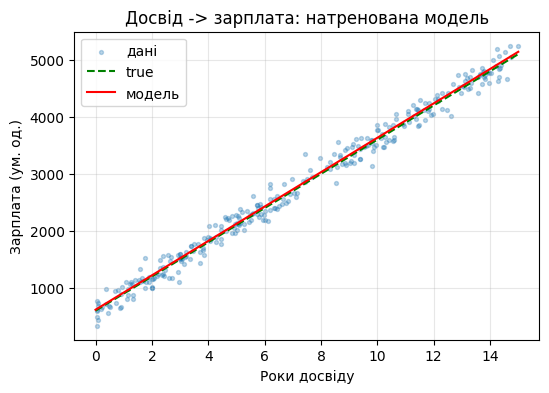

In [66]:
splits2 = split_train_val_test(x2, y2)
x_train2, y_train2 = splits2["train"]
x_val2, y_val2 = splits2["val"]
x_test2, y_test2 = splits2["test"]

print(f"train/val/test: {len(x_train2)}/{len(x_val2)}/{len(x_test2)}")

task2_model = train_linear_model(x_train2, y_train2, x_val2, y_val2, epochs=800, lr=0.01)
test_loss2 = evaluate_model(task2_model, x_test2, y_test2)

print(f"Натреновано: w={task2_model.weight.item():.3f} (true {TASK2_TRUE_W}), "
      f"b={task2_model.bias.item():.3f} (true {TASK2_TRUE_B})")

x_line2 = torch.linspace(0, 15, 100).unsqueeze(1)
with torch.no_grad():
    y_line2_pred = task2_model(x_line2)
    y_line2_true = TASK2_TRUE_W * x_line2 + TASK2_TRUE_B

plt.figure(figsize=(6, 4))
plt.scatter(x2.numpy(), y2.numpy(), s=8, alpha=0.3, label="дані")
plt.plot(x_line2.numpy(), y_line2_true.numpy(), "g--", label="true")
plt.plot(x_line2.numpy(), y_line2_pred.numpy(), "r-", label="модель")
plt.xlabel("Роки досвіду")
plt.ylabel("Зарплата (ум. од.)")
plt.title("Досвід -> зарплата: натренована модель")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [67]:
model_path = os.path.join(ARTIFACT_DIR, "model.pt")
torch.save(task2_model.state_dict(), model_path)
print("Модель збережено у:", model_path)


Модель збережено у: /content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [68]:
!pip install -q gradio
import gradio as gr

loaded_model = torch.nn.Linear(in_features=1, out_features=1)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()


def predict_salary(experience_years: float) -> float:
    with torch.no_grad():
        x_in = torch.tensor([[float(experience_years)]])
        pred = loaded_model(x_in).item()
    return round(pred, 2)


demo = gr.Interface(
    fn=predict_salary,
    inputs=gr.Slider(minimum=0, maximum=15, step=0.5, label="Роки досвіду"),
    outputs=gr.Number(label="Прогнозована зарплата (ум. од.)"),
    title="Досвід -> Зарплата",
    description="Лінійна регресія, натренована у Завданні 1 (Вправа 20).",
)
demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fefe23327f47dec2a3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```